<a href="https://colab.research.google.com/github/YoussefWael92/Skypredict/blob/main/Weather_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
weather = pd.read_csv("Los Angeles.csv", index_col = "DATE")

In [ ]:
weather

,STATION,NAME,ACMH,ACSH,AWND,FMTM,FRGT,PGTM,PRCP,SNOW,...,WT10,WT11,WT13,WT14,WT16,WT18,WT21,WV01,WV03,WV20
DATE,,,,,,,,,,,,,,,,,,,,,
1960-01-01,USW00023174,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,1112.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-02,USW00023174,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,1336.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-03,USW00023174,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,830.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-04,USW00023174,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,1506.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-05,USW00023174,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,1248.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-23,USW00023174,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",NaN,NaN,1.5,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-24,USW00023174,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",NaN,NaN,3.4,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-25,USW00023174,"LOS ANGELES INTERNATIONAL AIRPORT, CA US",NaN,NaN,2.0,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
weather.apply(pd.isnull).sum()/weather.shape[0]

,0
STATION,0.000000
NAME,0.000000
ACMH,0.504555
ACSH,0.504513
AWND,0.370044
FMTM,0.744010
FRGT,0.999958
PGTM,0.226759
PRCP,0.000042
SNOW,0.422347


In [ ]:
core_weather = weather[["PRCP", "SNOW", "SNWD", "TMAX", "TMIN"]].copy()

In [ ]:
core_weather.columns = ["precip", "snow", "snow_depth", "temp_min", "temp_max"]

In [ ]:
core_weather

,precip,snow,snow_depth,temp_min,temp_max
DATE,,,,,
1960-01-01,0.0,0.0,0.0,12.8,5.0
1960-01-02,0.0,0.0,0.0,13.9,2.2
1960-01-03,0.0,0.0,0.0,12.8,2.8
1960-01-04,0.0,0.0,0.0,16.1,3.9
1960-01-05,0.0,0.0,0.0,17.8,2.2
...,...,...,...,...,...
2024-11-23,0.0,NaN,NaN,16.1,9.4
2024-11-24,0.0,NaN,NaN,16.1,11.7
2024-11-25,0.0,NaN,NaN,21.1,10.6


In [ ]:
core_weather.apply(pd.isnull).sum()/core_weather.shape[0]

,0
precip,0.000042
snow,0.422347
snow_depth,0.394129
temp_min,0.000042
temp_max,0.000042


In [ ]:
core_weather["snow"].value_counts()

,count
snow,
0.0,13695


In [ ]:
del core_weather["snow"]

In [ ]:
del core_weather["snow_depth"]

In [ ]:
core_weather[pd.isnull(core_weather["precip"])]

,precip,temp_min,temp_max
DATE,,,
2024-11-27,NaN,NaN,NaN


In [ ]:
core_weather.loc["2024-11-1":"2024-12-1", :]

,precip,temp_min,temp_max
DATE,,,
2024-11-10,0.0,21.7,10.0
2024-11-11,0.0,18.9,8.9
2024-11-12,0.0,21.7,13.3
2024-11-13,0.0,25.6,12.2
2024-11-14,0.0,21.1,10.6
2024-11-15,0.0,17.2,12.2
2024-11-16,0.0,20.0,8.9
2024-11-17,0.0,20.6,7.2
2024-11-18,0.0,18.3,8.3


In [ ]:
core_weather[pd.isnull(core_weather["temp_max"])]

,precip,temp_min,temp_max
DATE,,,
2024-11-27,NaN,NaN,NaN


In [ ]:
core_weather = core_weather.ffill()

In [ ]:
core_weather.apply(pd.isnull).sum()/core_weather.shape[0]

,0
precip,0.0
temp_min,0.0
temp_max,0.0


In [ ]:
core_weather.dtypes

,0
precip,float64
temp_min,float64
temp_max,float64


In [ ]:
core_weather.index

Index(['1960-01-01', '1960-01-02', '1960-01-03', '1960-01-04', '1960-01-05',
       '1960-01-06', '1960-01-07', '1960-01-08', '1960-01-09', '1960-01-10',
       ...
       '2024-11-18', '2024-11-19', '2024-11-20', '2024-11-21', '2024-11-22',
       '2024-11-23', '2024-11-24', '2024-11-25', '2024-11-26', '2024-11-27'],
      dtype='object', name='DATE', length=23708)

In [ ]:
core_weather.index = pd.to_datetime(core_weather.index)

In [ ]:
core_weather.index

DatetimeIndex(['1960-01-01', '1960-01-02', '1960-01-03', '1960-01-04',
               '1960-01-05', '1960-01-06', '1960-01-07', '1960-01-08',
               '1960-01-09', '1960-01-10',
               ...
               '2024-11-18', '2024-11-19', '2024-11-20', '2024-11-21',
               '2024-11-22', '2024-11-23', '2024-11-24', '2024-11-25',
               '2024-11-26', '2024-11-27'],
              dtype='datetime64[ns]', name='DATE', length=23708, freq=None)

In [ ]:
core_weather.apply(lambda x:(x==9999).sum())

,0
precip,0
temp_min,0
temp_max,0


<Axes: xlabel='DATE'>

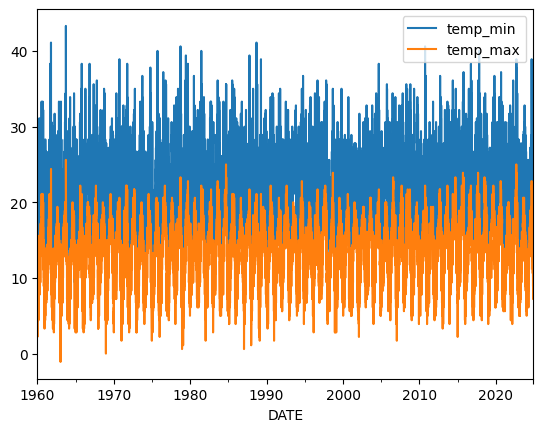

In [ ]:
core_weather[["temp_min", "temp_max"]].plot()

<Axes: xlabel='DATE'>

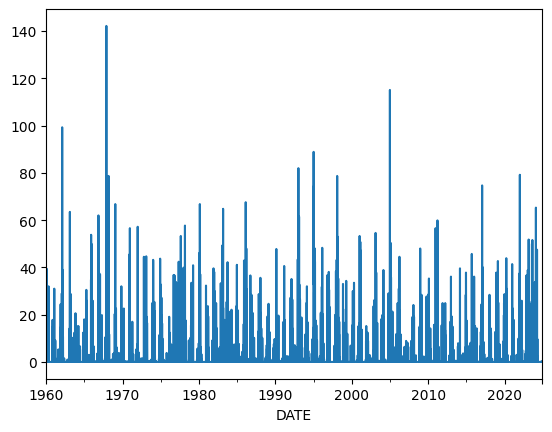

In [ ]:
core_weather["precip"].plot()

In [ ]:
core_weather.groupby(core_weather.index.year).sum()["precip"]

,precip
DATE,
1960,271.3
1961,128.4
1962,381.7
1963,343.6
1964,165.4
...,...
2020,229.6
2021,307.3
2022,162.8


In [ ]:
core_weather["target"] = core_weather.shift(-1)["precip"]

In [ ]:
core_weather

,precip,temp_min,temp_max,target
DATE,,,,
1960-01-01,0.0,12.8,5.0,0.0
1960-01-02,0.0,13.9,2.2,0.0
1960-01-03,0.0,12.8,2.8,0.0
1960-01-04,0.0,16.1,3.9,0.0
1960-01-05,0.0,17.8,2.2,0.0
...,...,...,...,...
2024-11-23,0.0,16.1,9.4,0.0
2024-11-24,0.0,16.1,11.7,0.0
2024-11-25,0.0,21.1,10.6,0.0


In [ ]:
core_weather = core_weather.iloc[:-1 :].copy()

In [ ]:
core_weather

,precip,temp_min,temp_max,target
DATE,,,,
1960-01-01,0.0,12.8,5.0,0.0
1960-01-02,0.0,13.9,2.2,0.0
1960-01-03,0.0,12.8,2.8,0.0
1960-01-04,0.0,16.1,3.9,0.0
1960-01-05,0.0,17.8,2.2,0.0
...,...,...,...,...
2024-11-22,0.0,21.1,8.3,0.0
2024-11-23,0.0,16.1,9.4,0.0
2024-11-24,0.0,16.1,11.7,0.0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import numpy as np


In [ ]:
predictors = ["precip", "temp_max", "temp_min"]
train = []

In [ ]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[predictors])
test_scaled = scaler.transform(test[predictors])

TypeError: list indices must be integers or slices, not list

In [ ]:
train = core_weather.loc[:"2023-12-31"]

In [ ]:
test = core_weather.loc["2024-01-01":]

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=None,        # Maximum depth of each tree
    random_state=42        # Ensures reproducibility
)

In [ ]:
rf.fit(train[predictors], train["target"])

RandomForestRegressor(random_state=42)

In [ ]:
predictions = rf.predict(test[predictors])


In [ ]:
mae = mean_absolute_error(test["target"], predictions)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 1.7794176714809313


In [ ]:
combined = pd.concat(
    [test["target"], pd.Series(predictions, index=test.index)],
    axis=1)

In [ ]:
combined.columns = ["actual", "predictions"]
print(combined)

            actual  predictions
DATE                           
2024-01-01     0.0     1.075732
2024-01-02     5.1     0.486141
2024-01-03     0.0     0.457000
2024-01-04     0.0     0.600756
2024-01-05     0.0     1.249065
...            ...          ...
2024-11-22     0.0     0.011307
2024-11-23     0.0     1.471858
2024-11-24     0.0     0.740559
2024-11-25     0.0     0.000000
2024-11-26     0.0     0.231566

[331 rows x 2 columns]


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,  # Cross-validation folds
    verbose=2,
    n_jobs=-1
)

grid_search.fit(train[predictors], train["target"])
best_rf = grid_search.best_estimator_


Fitting 3 folds for each of 81 candidates, totalling 243 fits
